<a href="https://colab.research.google.com/github/joannyvitorinounb-design/Controle-Estat-stico-de-Processos-2026.1/blob/main/MVP_CEP_vers%C3%A3o_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MVP - Produto Mínimo Viável**

**Tema: Avaliação da qualidade de um processo de usinagem industrial utilizando Controle Estatístico de Processos (CEP) e técnicas de Machine Learning.**

**Joanny Vitória Vitorino Duarte 222014302**

***TESTES E RESULTADOS INICIAIS***

***Importando as bibliotecas***

Nesta etapa são importadas as bibliotecas para análise dos dados, construção de gráficos e aplicação de técnicas de ML.

As bibliotecas Pandas e NumPy são utilizadas para manipulação e análise dos dados. As bibliotecas Matplotlib e Seaborn são utilizadas para construção das visualizações gráficas. Já a biblioteca Scikit-Learn é utilizada para aplicação do modelo de ML e avaliação dos resultados.

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

***Carregando e visualizando as bases de dados***

O conjunto de dados contém informações operacionais de um processo industrial de usinagem, incluindo variáveis relacionadas à temperatura, velocidade rotacional, torque, desgaste da ferramenta e registros de falhas da máquina.

In [200]:
df = pd.read_csv('ai4i2020.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

Foi realizada uma visualização inicial das primeiras linhas com o objetivo de compreender a estrutura do conjunto de dados, identificar as variáveis disponíveis e verificar se o carregamento deu certo.

Também foi utilizada a função info() para analisar a estrutura geral da base, verificando a quantidade de registros, os tipos das variáveis e a existência de valores ausentes.

Essa etapa é importante para garantir a qualidade dos dados antes das análises estatísticas e preditivas.

***Calculando estatísticas descritivas***

Foi realizada uma análise estatística descritiva das variáveis numéricas da base. Essa etapa permitiu observar medidas como média, desvio padrão, valores mínimos e máximos, contribuindo para a compreensão inicial do comportamento do processo produtivo.


In [201]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


***Verificando valores nulos***

Foi realizada uma verificação de valores nulos na base de dados para identificar possíveis inconsistências ou informações faltantes que poderiam comprometer as análises.


In [202]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


***Distribuindo as falhas***

Foi realizada uma análise da variável de falha da máquina com o objetivo de verificar a distribuição entre registros com falha e sem falha no processo produtivo.

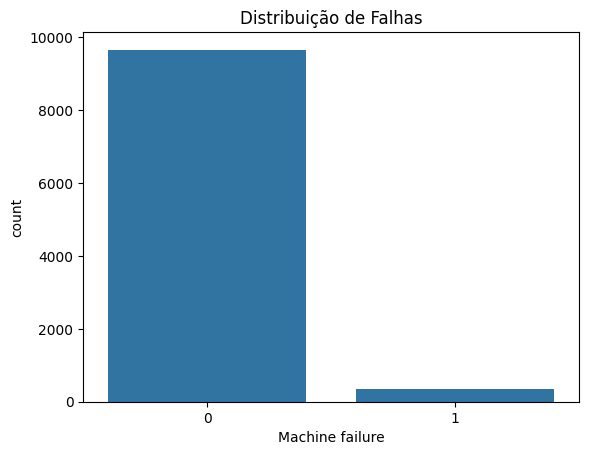

In [203]:
df['Machine failure'].value_counts()

sns.countplot(x='Machine failure', data=df)
plt.title('Distribuição de Falhas')
plt.show()

Observa-se predominância de registros sem falha em relação às ocorrências de falha da máquina, caracterizando um cenário de desbalanceamento entre as classes.

**CARTAS DE CONTROLE**

O objetivo da carta de controle é monitorar a estabilidade do processo produtivo e identificar possíveis variações anormais nas condições operacionais da usinagem industrial. As cartas foram construídas utilizando a média da variável como linha central e limites de controle calculados com base em três desvios padrão.

- Linha central: representa a média do processo;
- Limite Superior de Controle (LSC): representa o limite máximo esperado para a variabilidade natural do processo;
- Limite Inferior de Controle (LIC): representa o limite mínimo esperado para a variabilidade natural do processo.

Observações fora desses limites podem indicar a presença de causas especiais de variação, sugerindo possíveis instabilidades operacionais, desgaste do sistema ou condições associadas a falhas da máquina. Além dos pontos fora de controle, também são analisados padrões de tendência, dispersão e comportamento das variáveis ao longo das amostras.

*Carta de controle - Torque*

A variável Torque representa o esforço mecânico aplicado durante o processo de usinagem industrial. O monitoramento do torque é relevante porque aumentos excessivos de carga mecânica podem indicar alterações operacionais, desgaste da ferramenta ou condições inadequadas de funcionamento do sistema.

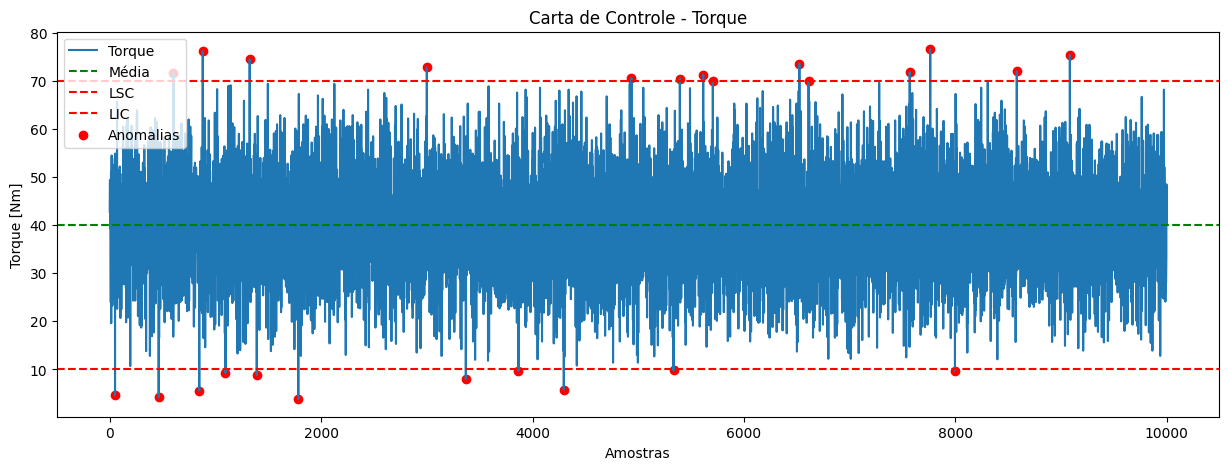

,count
Machine failure,
1,24
0,1


In [204]:
media = df['Torque [Nm]'].mean()
desvio = df['Torque [Nm]'].std()
LSC = media + 3*desvio
LIC = media - 3*desvio

plt.figure(figsize=(15,5))
plt.plot(df['Torque [Nm]'], label='Torque')
plt.axhline(media, color='green', linestyle='--', label='Média')
plt.axhline(LSC, color='red', linestyle='--', label='LSC')
plt.axhline(LIC, color='red', linestyle='--', label='LIC')
anomalias = df[
    (df['Torque [Nm]'] > LSC) |
    (df['Torque [Nm]'] < LIC)
]
plt.scatter(
    anomalias.index,
    anomalias['Torque [Nm]'],
    color='red',
    label='Anomalias'
)
plt.title('Carta de Controle - Torque')
plt.xlabel('Amostras')
plt.ylabel('Torque [Nm]')
plt.legend()
plt.show()

anomalias[['Torque [Nm]', 'Machine failure']]
anomalias['Machine failure'].value_counts()
anomalias = df[
    (df['Torque [Nm]'] > LSC) |
    (df['Torque [Nm]'] < LIC)
]
anomalias['Machine failure'].value_counts()

Observa-se que parte das amostras ultrapassou os limites estatísticos de controle estabelecidos para o processo. Ao analisar os pontos identificados como fora de controle, observa-se que parte dessas ocorrências coincide com registros de falha da máquina. Esse comportamento sugere que desvios significativos nas variáveis operacionais podem estar relacionados ao surgimento de falhas no processo produtivo, como a mudanças nas condições de usinagem, sobrecarga operacional ou degradação progressiva dos componentes do sistema, reforçando a importância do monitoramento estatístico contínuo.

Além da presença de anomalias pontuais, observa-se elevada variabilidade nas medições operacionais, indicando instabilidade estatística do processo. Altos níveis de dispersão podem comprometer a previsibilidade operacional e aumentar a probabilidade de ocorrência de falhas ou perda de qualidade no processo produtivo.

***Carta de controle - Desgaste da ferramenta***

A variável Tool wear representa o nível de desgaste acumulado da ferramenta de usinagem ao longo da operação industrial. O monitoramento dessa variável é relevante pois níveis elevados de desgaste podem impactar diretamente a qualidade do produto, aumentar esforços mecânicos e elevar a probabilidade de falhas operacionais.

(0, 14)


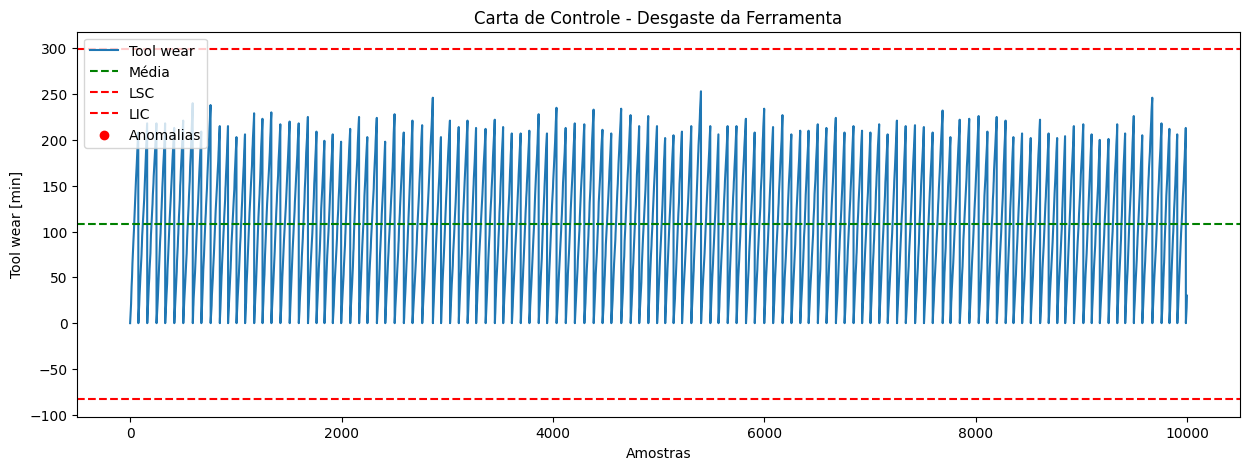

,count
Machine failure,


In [205]:
media_tool = df['Tool wear [min]'].mean()
desvio_tool = df['Tool wear [min]'].std()
LSC_tool = media_tool + 3*desvio_tool
LIC_tool = media_tool - 3*desvio_tool

anomalias_tool = df[
    (df['Tool wear [min]'] > LSC_tool) |
    (df['Tool wear [min]'] < LIC_tool)
]
print(anomalias_tool.shape)

plt.figure(figsize=(15,5))
plt.plot(df['Tool wear [min]'],
         label='Tool wear')
plt.axhline(media_tool,
            color='green',
            linestyle='--',
            label='Média')
plt.axhline(LSC_tool,
            color='red',
            linestyle='--',
            label='LSC')
plt.axhline(LIC_tool,
            color='red',
            linestyle='--',
            label='LIC')
plt.scatter(
    anomalias_tool.index,
    anomalias_tool['Tool wear [min]'],
    color='red',
    label='Anomalias'
)
plt.title('Carta de Controle - Desgaste da Ferramenta')
plt.xlabel('Amostras')
plt.ylabel('Tool wear [min]')
plt.legend()
plt.show()

anomalias_tool['Machine failure'].value_counts()

Observa-se a presença de pontos próximos dos limites de controle, indicando possíveis condições operacionais associadas à degradação progressiva da ferramenta.

Além das anomalias pontuais, nota-se tendência gradual de crescimento da variável em determinados intervalos, comportamento compatível com processos de desgaste contínuo em operações de usinagem industrial. Esse padrão sugere redução progressiva da estabilidade operacional, podendo impactar diretamente a qualidade do processo e aumentar o risco de falhas mecânicas.

Parte das observações identificadas como fora de controle apresenta associação com registros de falha da máquina, sugerindo que níveis elevados de desgaste podem atuar como indicadores antecedentes de degradação operacional.

***Carta de Controle - velocidade de rotação***

A variável Rotational speed representa a velocidade de rotação do equipamento durante o processo produtivo. A estabilidade dessa variável é importante para garantir condições adequadas de usinagem, pois oscilações excessivas podem comprometer a qualidade operacional e gerar esforços mecânicos adicionais no sistema.

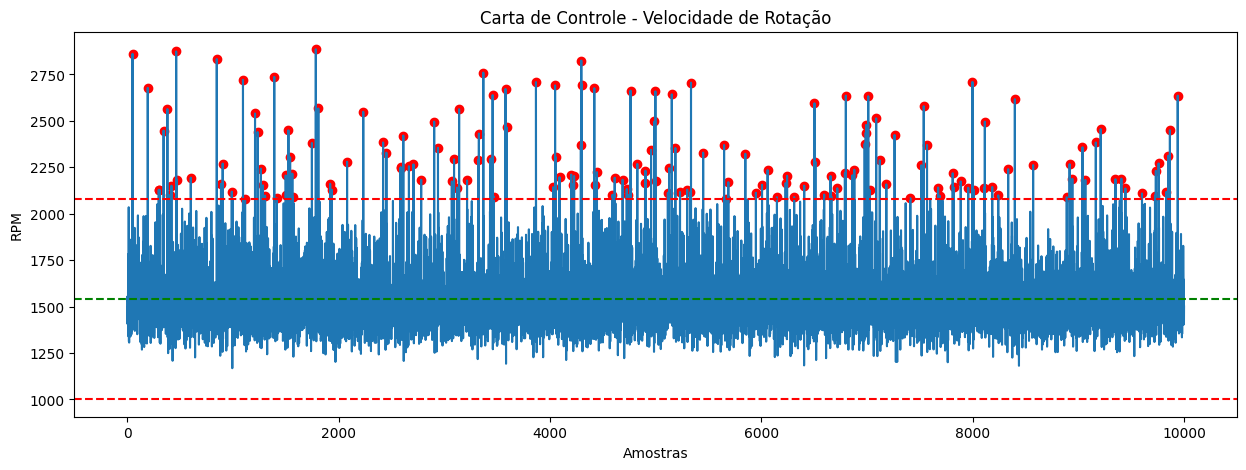

In [206]:
media_rot = df['Rotational speed [rpm]'].mean()
desvio_rot = df['Rotational speed [rpm]'].std()
LSC_rot = media_rot + 3*desvio_rot
LIC_rot = media_rot - 3*desvio_rot

anomalias_rot = df[
    (df['Rotational speed [rpm]'] > LSC_rot) |
    (df['Rotational speed [rpm]'] < LIC_rot)
]

plt.figure(figsize=(15,5))
plt.plot(df['Rotational speed [rpm]'])
plt.axhline(media_rot,
            color='green',
            linestyle='--')
plt.axhline(LSC_rot,
            color='red',
            linestyle='--')
plt.axhline(LIC_rot,
            color='red',
            linestyle='--')
plt.scatter(
    anomalias_rot.index,
    anomalias_rot['Rotational speed [rpm]'],
    color='red'
)
plt.title('Carta de Controle - Velocidade de Rotação')
plt.xlabel('Amostras')
plt.ylabel('RPM')
plt.show()

A análise da velocidade rotacional evidencia oscilações operacionais ao longo do processo produtivo. Embora grande parte das observações permaneça dentro dos limites estatísticos de controle, observa-se presença de dispersões relevantes e pontos extremos, indicando possíveis instabilidades operacionais.

Em processos industriais de usinagem, variações excessivas de velocidade podem alterar as condições de corte, aumentar vibrações mecânicas e impactar negativamente a estabilidade do sistema produtivo.

***Carta de controle - Tempetratura do Processo***

A variável Process temperature representa a temperatura operacional do processo produtivo durante a usinagem. O monitoramento dessa variável é importante porque aumentos excessivos de temperatura podem indicar sobrecarga operacional, atrito elevado ou condições inadequadas de funcionamento do equipamento.

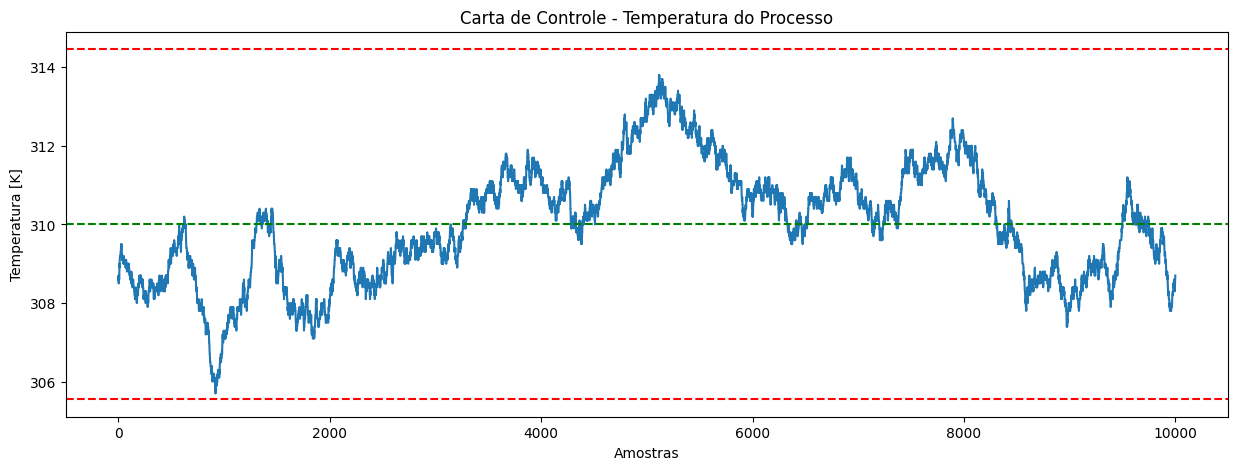

In [207]:
media_temp = df['Process temperature [K]'].mean()
desvio_temp = df['Process temperature [K]'].std()
LSC_temp = media_temp + 3*desvio_temp
LIC_temp = media_temp - 3*desvio_temp

anomalias_temp = df[
    (df['Process temperature [K]'] > LSC_temp) |
    (df['Process temperature [K]'] < LIC_temp)
]

plt.figure(figsize=(15,5))
plt.plot(df['Process temperature [K]'])
plt.axhline(media_temp,
            color='green',
            linestyle='--')
plt.axhline(LSC_temp,
            color='red',
            linestyle='--')
plt.axhline(LIC_temp,
            color='red',
            linestyle='--')
plt.scatter(
    anomalias_temp.index,
    anomalias_temp['Process temperature [K]'],
    color='red'
)
plt.title('Carta de Controle - Temperatura do Processo')
plt.xlabel('Amostras')
plt.ylabel('Temperatura [K]')
plt.show()

A carta de controle da temperatura do processo evidencia comportamento relativamente variável associado a possíveis condições anormais de operação.

Variações significativas de temperatura podem indicar aumento de atrito mecânico, sobrecarga do sistema ou alterações nas condições de usinagem. Além disso, desvios térmicos podem contribuir para degradação do equipamento e redução da confiabilidade operacional do processo produtivo.

A análise conjunta das cartas de controle indica que o processo produtivo não apresenta estabilidade estatística completamente uniforme ao longo das observações analisadas.

Embora parte significativa das amostras permaneça dentro dos limites de controle, observam-se regiões com elevada variabilidade operacional, presença de pontos extremos e tendências associadas à degradação progressiva de determinadas variáveis operacionais.

Esses comportamentos sugerem a ocorrência de causas especiais de variação, indicando possíveis alterações nas condições de usinagem, desgaste acumulado da ferramenta e mudanças no esforço operacional do sistema produtivo.

***Fazendo o heatmap de correlação***

Foi elaborada uma matriz de correlação entre as variáveis numéricas do processo produtivo. O objetivo foi identificar relações entre as variáveis operacionais e possíveis associações com as falhas da máquina.

<Axes: >

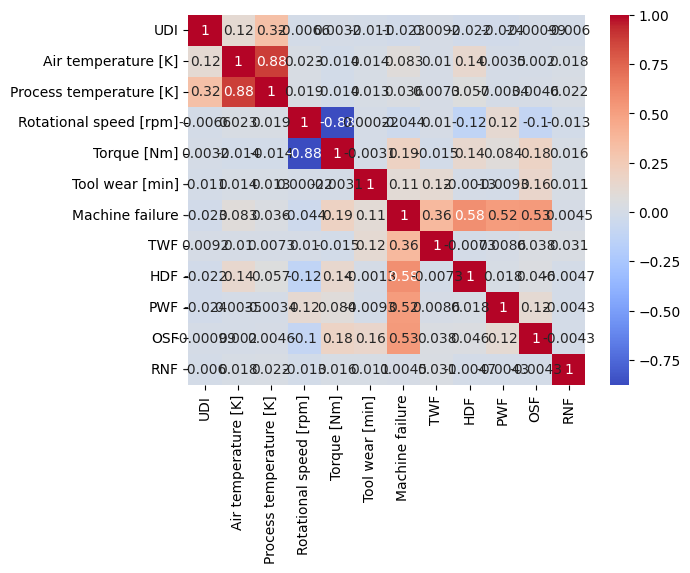

In [208]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

Observou-se que algumas variáveis apresentam associação moderada com a ocorrência de falhas da máquina, indicando potencial relevância para aplicações preditivas.

Além disso, a análise evidencia possíveis relações entre desgaste da ferramenta, torque e comportamento operacional do equipamento, fatores frequentemente associados à degradação do processo produtivo.

***Machine Learning***

Além da análise estatística, foi desenvolvido um modelo de Machine Learning com o objetivo de identificar padrões operacionais associados à ocorrência de falhas da máquina. A utilização de técnicas preditivas permite complementar a análise estatística tradicional, possibilitando detectar comportamentos anormais do processo produtivo e apoiar estratégias de manutenção preditiva e monitoramento contínuo da qualidade industrial.


Foram selecionadas as principais variáveis operacionais do processo produtivo como entradas do modelo preditivo, enquanto a variável "Machine failure" foi utilizada como variável alvo para classificação das falhas.

In [209]:
X = df[['Air temperature [K]',
        'Process temperature [K]',
        'Rotational speed [rpm]',
        'Torque [Nm]',
        'Tool wear [min]']]

y = df['Machine failure']

***Separando treino e teste***

Os dados foram divididos em conjuntos de treino e teste, utilizando 70% das observações para treinamento do modelo e 30% para validação. A utilização do parâmetro stratify permitiu preservar a proporção original entre registros com e sem falha, reduzindo impactos do desbalanceamento durante a avaliação do modelo.


In [210]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

***Treinando e fazendo a previsão do modelo***

Foi utilizado o algoritmo Random Forest para treinamento do modelo preditivo de falhas. Este é um método baseado em múltiplas árvores de decisão, sendo amplamente utilizado em problemas de classificação devido à sua capacidade de lidar com relações não lineares e variáveis operacionais complexas.

In [211]:
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

modelo.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

***Previsões***

Além da classificação das observações, o modelo também foi utilizado para estimar probabilidades associadas à ocorrência de falhas.

In [212]:
pred = modelo.predict(X_test)
probabilidades = modelo.predict_proba(X_test)
prob_falha = probabilidades[:,1]

resultado_prob = pd.DataFrame({
    'Probabilidade de falha': prob_falha
})
resultado_prob.head(10)

resultado_prob['Probabilidade de falha (%)'] = (
    resultado_prob['Probabilidade de falha'] * 100
)
resultado_prob.head(10)

def classificar_risco(prob):
    if prob < 0.2:
        return 'Baixo risco'
    elif prob < 0.5:
        return 'Médio risco'
    else:
        return 'Alto risco'
resultado_prob['Nível de risco'] = (
    resultado_prob['Probabilidade de falha']
    .apply(classificar_risco)
)
resultado_prob.head(10)

,Probabilidade de falha,Probabilidade de falha (%),Nível de risco
0,0.000648,0.064828,Baixo risco
1,0.001183,0.118334,Baixo risco
2,0.001154,0.115350,Baixo risco
3,0.003606,0.360564,Baixo risco
4,0.000878,0.087751,Baixo risco
5,0.000488,0.048840,Baixo risco
6,0.644842,64.484154,Alto risco
7,0.000585,0.058481,Baixo risco
8,0.000608,0.060812,Baixo risco
9,0.001332,0.133208,Baixo risco


Observa-se que parte das amostras apresentou baixa probabilidade de falha, indicando comportamento compatível com condições normais de operação. Entretanto, algumas observações apresentaram probabilidades significativamente mais elevadas, sugerindo possíveis condições de degradação operacional ou maior risco de falha da máquina.

No contexto industrial, esse tipo de análise possui elevada relevância para aplicações de manutenção preditiva, pois permite priorizar intervenções em condições operacionais consideradas mais críticas antes da ocorrência de falhas efetivas.

In [213]:
resultado_prob.sort_values(
    by='Probabilidade de falha (%)',
    ascending=False
).head(10)

,Probabilidade de falha,Probabilidade de falha (%),Nível de risco
682,0.970000,97.000000,Alto risco
961,0.970000,97.000000,Alto risco
380,0.960023,96.002336,Alto risco
1415,0.940000,94.000000,Alto risco
237,0.940000,94.000000,Alto risco
2835,0.930000,93.000000,Alto risco
1457,0.930000,93.000000,Alto risco
2697,0.925738,92.573810,Alto risco
2155,0.920000,92.000000,Alto risco
1067,0.911429,91.142857,Alto risco


Observa-se que observações associadas a maiores probabilidades de falha frequentemente coincidem com comportamentos anormais previamente identificados nas cartas de controle, especialmente em variáveis relacionadas ao torque e desgaste da ferramenta. Esse comportamento reforça a relação entre instabilidade operacional e aumento do risco de falhas no processo produtivo.

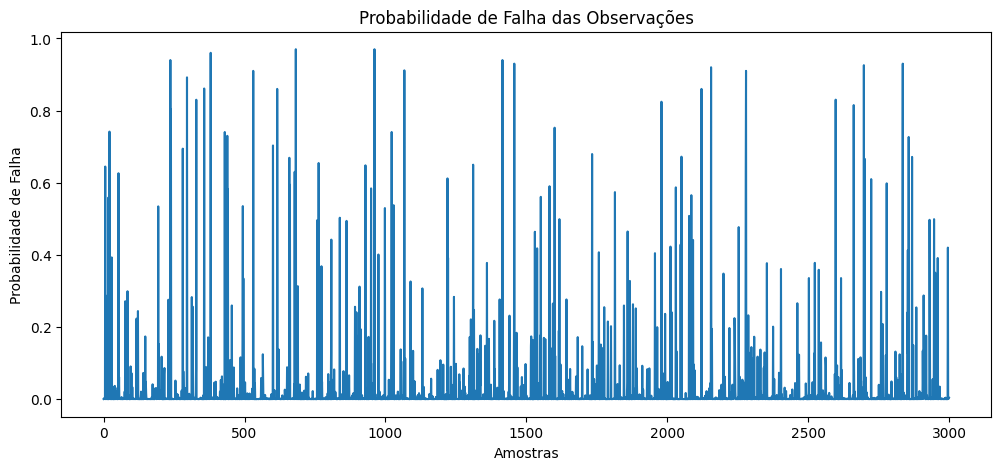

In [214]:
plt.figure(figsize=(12,5))

plt.plot(prob_falha)

plt.title('Probabilidade de Falha das Observações')
plt.xlabel('Amostras')
plt.ylabel('Probabilidade de Falha')

plt.show()

A análise gráfica das probabilidades previstas evidencia que o modelo atribui níveis distintos de risco às condições operacionais observadas.

Enquanto grande parte das amostras apresenta baixa probabilidade de falha, determinadas observações concentram valores significativamente mais elevados, indicando possíveis condições críticas de operação.

***Avaliando o modelo***

O desempenho do modelo foi avaliado por meio da matriz de confusão e das métricas de classificação.

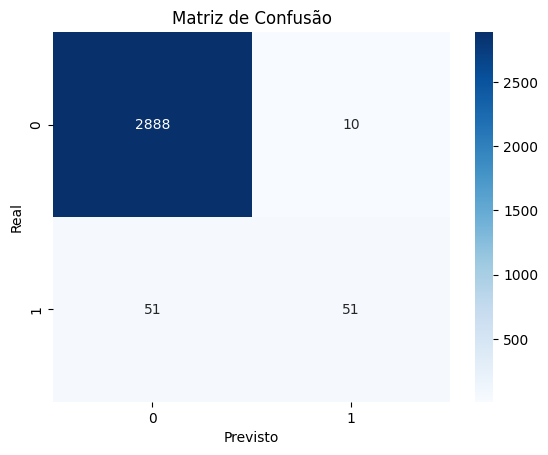

In [215]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

In [216]:
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[2888   10]
 [  51   51]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2898
           1       0.84      0.50      0.63       102

    accuracy                           0.98      3000
   macro avg       0.91      0.75      0.81      3000
weighted avg       0.98      0.98      0.98      3000



Os resultados demonstram a capacidade do modelo em reconhecer padrões associados ao comportamento operacional da máquina, embora ainda existam ocorrências de classificações incorretas.

No contexto industrial, os falsos negativos representam uma limitação importante do modelo, pois correspondem a situações em que falhas reais não são identificadas pelo sistema preditivo.

Ainda, em aplicações industriais, métricas como recall possuem elevada relevância, pois representam a capacidade do sistema em detectar falhas reais antes que ocorram impactos significativos no processo produtivo.

O F1-score representa o equilíbrio entre precision e recall, permitindo avaliar o desempenho geral do modelo na identificação das falhas operacionais.

Embora o modelo apresente desempenho satisfatório, os falsos negativos merecem atenção especial, pois representam situações em que falhas reais não são detectadas pelo sistema preditivo. Em aplicações industriais, esse tipo de erro pode resultar em falhas inesperadas, aumento de custos operacionais e interrupções não planejadas da produção.

***Análise das variáveis***

A análise de importância das variáveis permitiu identificar quais fatores operacionais possuem maior influência na previsão de falhas da máquina.

                  Variável  Importância
3              Torque [Nm]     0.364379
2   Rotational speed [rpm]     0.224384
4          Tool wear [min]     0.161698
1  Process temperature [K]     0.128555
0      Air temperature [K]     0.120984


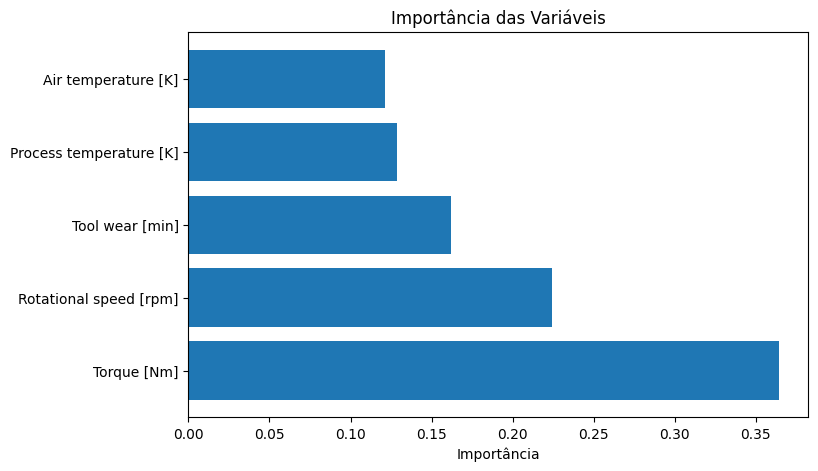

In [217]:
importances = modelo.feature_importances_
importancia_df = pd.DataFrame({
    'Variável': X.columns,
    'Importância': importances
})
importancia_df = importancia_df.sort_values(
    by='Importância',
    ascending=False
)
print(importancia_df)


plt.figure(figsize=(8,5))
plt.barh(
    importancia_df['Variável'],
    importancia_df['Importância']
)
plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.show()

Observa-se que variáveis relacionadas ao esforço mecânico, desgaste operacional e condições térmicas apresentam maior relevância no comportamento preditivo do modelo.

Esses resultados reforçam a relação entre degradação operacional e ocorrência de falhas industriais, além de indicar quais parâmetros podem ser priorizados em estratégias de monitoramento contínuo do processo produtivo.

***Comparação entre processo normal e falha***

A comparação entre condições normais de operação e registros de falha evidencia diferenças relevantes no comportamento das variáveis operacionais.

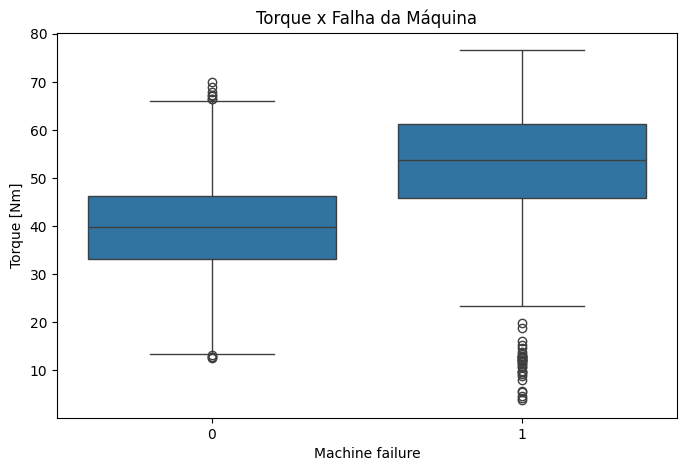

In [218]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Machine failure',
    y='Torque [Nm]',
    data=df
)

plt.title('Torque x Falha da Máquina')

plt.show()

Observa-se que situações associadas a falhas apresentam maior dispersão e maior instabilidade operacional, indicando comportamento distinto em relação ao funcionamento normal do processo produtivo.

***Conclusão parcial do MVP***

Apesar dos resultados obtidos demonstrarem potencial para aplicação em monitoramento industrial, o modelo desenvolvido ainda apresenta caráter inicial e experimental, podendo ser aprimorado por meio de ajustes de parâmetros, balanceamento das classes e comparação com outros algoritmos de classificação.

Além disso, a base utilizada representa um ambiente simulado de manutenção preditiva, não reproduzindo integralmente todas as variabilidades presentes em operações industriais reais.

Dessa forma, os resultados devem ser interpretados como evidências preliminares de comportamento operacional e potencial aplicação das técnicas utilizadas.